# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.gridspec as gridspec
import matplotlib.gridspec as gridspec
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_train = pd.read_csv("../dataset/train.csv")
df_test  = pd.read_csv("../dataset/test.csv")

DATASET OVERVIEW
Train shape : (2000, 8)
Test shape  : (500, 7)
Train columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns  : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

MISSING VALUES
Train:
 id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Test:
 id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

SAMPLE ROWS (train)
   id                                                                                                                                                                                  prompt                                                                                                                                                                                                                                                                                                                                                                          

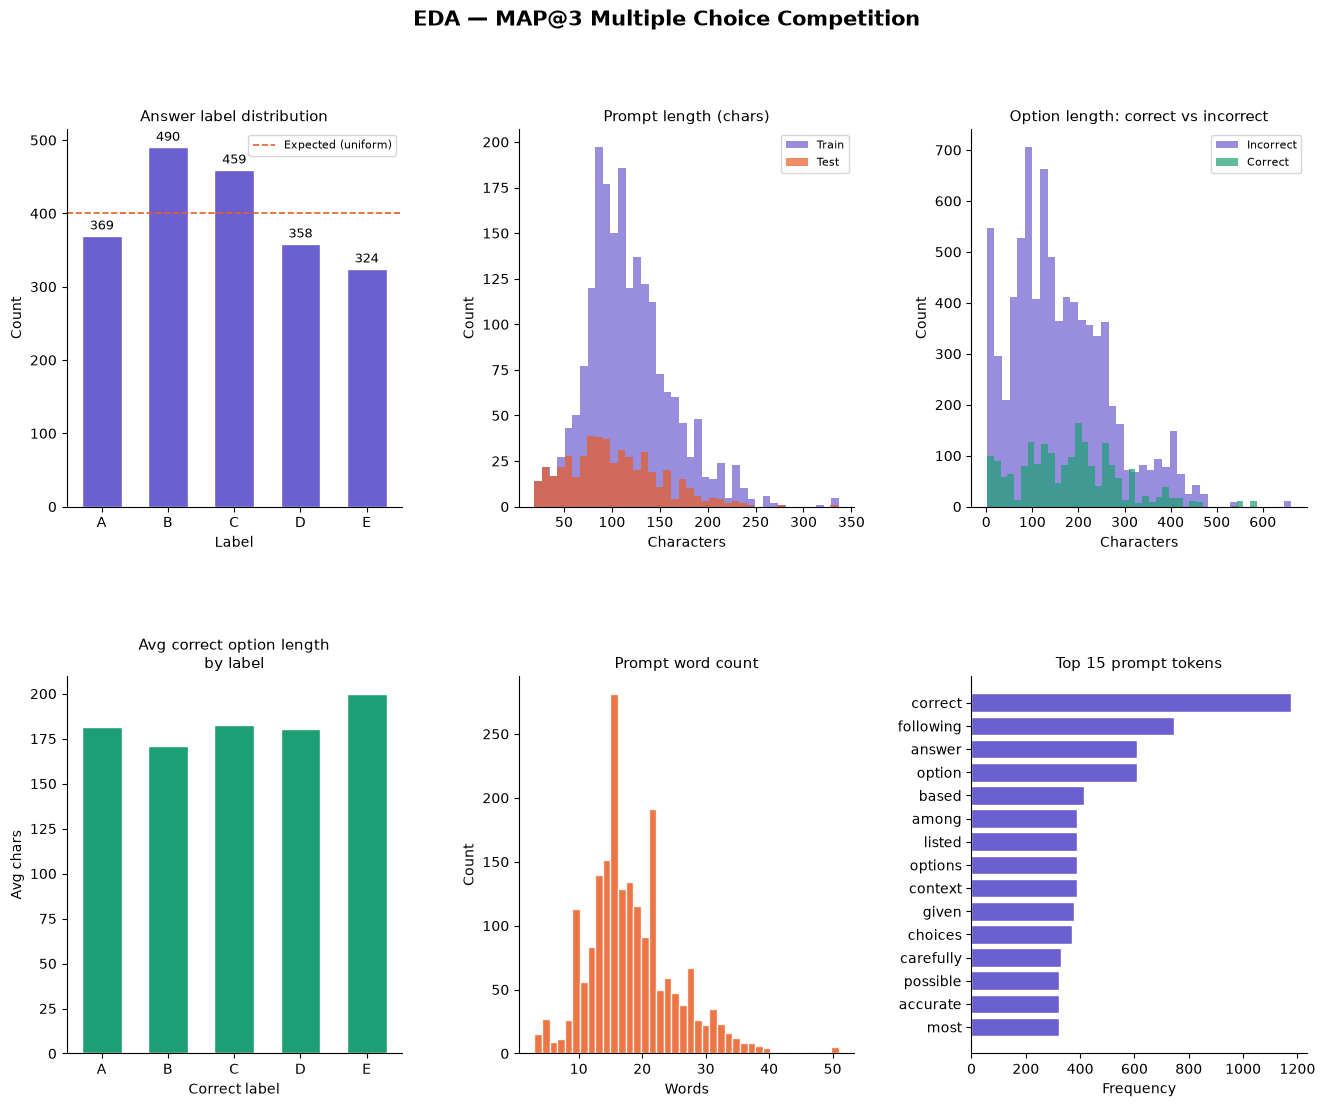

In [4]:
CHOICES = ["A", "B", "C", "D", "E"]

print("DATASET OVERVIEW")
print(f"Train shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")
print(f"Train columns : {list(df_train.columns)}")
print(f"Test columns  : {list(df_test.columns)}")

print("\nMISSING VALUES")
print("Train:\n", df_train.isnull().sum())
print("\nTest:\n", df_test.isnull().sum())

print("\nSAMPLE ROWS (train)")
pd.set_option("display.max_colwidth", 80)
print(df_train.head(3).to_string())

print("\nANSWER LABEL DISTRIBUTION")
ans_counts = df_train["answer"].value_counts().sort_index()
ans_pct    = (ans_counts / len(df_train) * 100).round(1)
for label in CHOICES:
    count = ans_counts.get(label, 0)
    pct   = ans_pct.get(label, 0.0)
    bar   = "█" * int(pct / 2)
    print(f"  {label}: {count:>5}  ({pct:>5.1f}%)  {bar}")

print("\nTEXT LENGTH ANALYSIS (characters)")

df_train["prompt_len"]  = df_train["prompt"].str.len()
df_train["options_len"] = df_train[CHOICES].apply(lambda r: r.str.len().mean(), axis=1)
df_test["prompt_len"]   = df_test["prompt"].str.len()
df_test["options_len"]  = df_test[CHOICES].apply(lambda r: r.str.len().mean(), axis=1)

for name, df in [("Train", df_train), ("Test", df_test)]:
    print(f"\n{name} — prompt length:")
    print(f"mean={df['prompt_len'].mean():.0f}  "
          f"median={df['prompt_len'].median():.0f}  "
          f"min={df['prompt_len'].min()}  "
          f"max={df['prompt_len'].max()}")
    print(f"{name} — avg option length:")
    print(f"  mean={df['options_len'].mean():.0f}  "
          f"median={df['options_len'].median():.0f}  "
          f"min={df['options_len'].min():.0f}  "
          f"max={df['options_len'].max():.0f}")

print("\nOPTION LENGTH BIAS")
print("Avg character length of correct vs incorrect options:")

correct_lens   = []
incorrect_lens = []
for _, row in df_train.iterrows():
    for c in CHOICES:
        l = len(str(row[c]))
        if c == row["answer"]:
            correct_lens.append(l)
        else:
            incorrect_lens.append(l)

print(f"Correct options: mean={np.mean(correct_lens):.1f}  "
      f"median={np.median(correct_lens):.1f}")
print(f"Incorrect options: mean={np.mean(incorrect_lens):.1f}  "
      f"median={np.median(incorrect_lens):.1f}")

print("\nDUPLICATE CHECK")
dup_prompts = df_train["prompt"].duplicated().sum()
print(f"Duplicate prompts in train : {dup_prompts}")
train_test_overlap = set(df_train["prompt"]) & set(df_test["prompt"])
print(f"Train/test prompt overlap  : {len(train_test_overlap)}")

def word_count(text):
    return len(str(text).split())

df_train["prompt_words"] = df_train["prompt"].apply(word_count)
print("\nWORD COUNT (prompt)")
print(f"mean={df_train['prompt_words'].mean():.1f}  "
      f"median={df_train['prompt_words'].median():.1f}  "
      f"max={df_train['prompt_words'].max()}")

df_train["approx_tokens"] = (df_train["prompt_words"] / 0.75).astype(int)
long_ctx = (df_train["approx_tokens"] > 400).sum()
print(f"  Questions with >400 approx tokens : {long_ctx} "
      f"({long_ctx/len(df_train)*100:.1f}%) — may need truncation")

stopwords = {"the","a","an","is","are","was","were","of","to","in","and",
             "or","that","it","be","as","at","by","for","with","on","from",
             "this","which","what","how","do","does","not","no","can","will"}

all_words = []
for p in df_train["prompt"]:
    words = re.findall(r"[a-z]+", str(p).lower())
    all_words.extend([w for w in words if w not in stopwords and len(w) > 2])

top_words = Counter(all_words).most_common(20)
print("\nTOP 20 NON-STOPWORD TOKENS IN PROMPTS")
for word, cnt in top_words:
    bar = "▪" * min(cnt // max(1, top_words[-1][1]), 30)
    print(f"  {word:<20} {cnt:>5}  {bar}")

fig = plt.figure(figsize=(16, 12))
fig.suptitle("EDA — MAP@3 Multiple Choice Competition", fontsize=15, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
colors = ["#6C5FCF", "#6C5FCF", "#6C5FCF", "#6C5FCF", "#6C5FCF"]
bars = ax1.bar(ans_counts.index, ans_counts.values, color=colors, edgecolor="white", width=0.6)
ax1.axhline(len(df_train) / 5, color="#E85D24", linestyle="--", linewidth=1.2, label="Expected (uniform)")
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
ax1.set_title("Answer label distribution", fontsize=11)
ax1.set_xlabel("Label"); ax1.set_ylabel("Count")
ax1.legend(fontsize=8)
ax1.spines[["top","right"]].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_train["prompt_len"], bins=40, alpha=0.7, color="#6C5FCF", label="Train")
ax2.hist(df_test["prompt_len"],  bins=40, alpha=0.7, color="#E85D24", label="Test")
ax2.set_title("Prompt length (chars)", fontsize=11)
ax2.set_xlabel("Characters"); ax2.set_ylabel("Count")
ax2.legend(fontsize=8)
ax2.spines[["top","right"]].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(incorrect_lens, bins=40, alpha=0.7, color="#6C5FCF", label="Incorrect")
ax3.hist(correct_lens,   bins=40, alpha=0.7, color="#1D9E75", label="Correct")
ax3.set_title("Option length: correct vs incorrect", fontsize=11)
ax3.set_xlabel("Characters"); ax3.set_ylabel("Count")
ax3.legend(fontsize=8)
ax3.spines[["top","right"]].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0])
avg_len_by_label = {c: df_train[df_train["answer"]==c][c].str.len().mean() for c in CHOICES}
ax4.bar(avg_len_by_label.keys(), avg_len_by_label.values(),
        color="#1D9E75", edgecolor="white", width=0.6)
ax4.set_title("Avg correct option length\nby label", fontsize=11)
ax4.set_xlabel("Correct label"); ax4.set_ylabel("Avg chars")
ax4.spines[["top","right"]].set_visible(False)

ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df_train["prompt_words"], bins=40, color="#E85D24", edgecolor="white", alpha=0.85)
ax5.set_title("Prompt word count", fontsize=11)
ax5.set_xlabel("Words"); ax5.set_ylabel("Count")
ax5.spines[["top","right"]].set_visible(False)

ax6 = fig.add_subplot(gs[1, 2])
words15, counts15 = zip(*top_words[:15])
ax6.barh(list(reversed(words15)), list(reversed(counts15)),
         color="#6C5FCF", edgecolor="white")
ax6.set_title("Top 15 prompt tokens", fontsize=11)
ax6.set_xlabel("Frequency")
ax6.spines[["top","right"]].set_visible(False)

plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
print("\nPlot saved to eda_plots.png")
print("\nEDA complete.")

In [4]:
CHOICES = ["A", "B", "C", "D", "E"]

ans_counts = df_train["answer"].value_counts()
most_freq = ans_counts.max()
least_freq = ans_counts.min()
print(f"Q1: Sum of most and least frequent option occurrences: {most_freq + least_freq}")

def clean_and_split(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.split()

all_unique_words = set()
for prompt in df_train["prompt"]:
    all_unique_words.update(clean_and_split(prompt))
print(f"Q2: Total unique words in cleaned prompts: {len(all_unique_words)}")

row_1_words = clean_and_split(df_train.loc[1, "prompt"])
filtered_row_1 = [w for w in row_1_words if w not in ENGLISH_STOP_WORDS]
print(f"Q3: Words left in Row 1 prompt after stop-word filtering: {len(filtered_row_1)}")

combined_text = []
for _, row in df_train.iterrows():
    combined_text.append(str(row["prompt"]))
    for c in CHOICES:
        combined_text.append(str(row[c]))

vectorizer = TfidfVectorizer(stop_words='english')
vectorizer.fit(combined_text)
print(f"Q4: Total number of feature columns (vocab size): {len(vectorizer.get_feature_names_out())}")

prompt_1_vec = vectorizer.transform([str(df_train.loc[1, "prompt"])])
option_A_1_vec = vectorizer.transform([str(df_train.loc[1, "A"])])
cos_sim_1_A = cosine_similarity(prompt_1_vec, option_A_1_vec)[0][0]
print(f"Q5: Cosine similarity for Row 1 (Prompt vs Option A): {cos_sim_1_A:.4f}")

correct_predictions = 0
for _, row in df_train.iterrows():
    p_vec = vectorizer.transform([str(row["prompt"])])
    similarities = []
    for c in CHOICES:
        opt_vec = vectorizer.transform([str(row[c])])
        sim = cosine_similarity(p_vec, opt_vec)[0][0]
        similarities.append((c, sim))
        
    similarities.sort(key=lambda x: x[1], reverse=True)
    best_guess = similarities[0][0]
    
    if best_guess == row["answer"]:
        correct_predictions += 1

accuracy = (correct_predictions / len(df_train)) * 100
print(f"Q6: Percentage where highest cosine similarity matches correct answer: {accuracy:.2f}%")

def map_at_3(ground_truth, predictions):
    score = 0.0
    for i, p in enumerate(predictions[:3]):
        if p == ground_truth:
            score = 1.0 / (i + 1)
            break
    return score

print(f"Q7: MAP@3 score if truth is C and prediction is [C, A, B]: {map_at_3('C', ['C', 'A', 'B']):.4f}")

print(f"Q8: MAP@3 score if truth is B and prediction is [D, B, E]: {map_at_3('B', ['D', 'B', 'E']):.4f}")

top_3_overall = ans_counts.head(3).index.tolist()
majority_map3_scores = [map_at_3(truth, top_3_overall) for truth in df_train["answer"]]
print(f"Q9: Overall MAP@3 score for Majority Class Baseline: {np.mean(majority_map3_scores):.4f}")

tfidf_map3_scores = []
for _, row in df_train.iterrows():
    p_vec = vectorizer.transform([str(row["prompt"])])
    similarities = []
    for c in CHOICES:
        opt_vec = vectorizer.transform([str(row[c])])
        sim = cosine_similarity(p_vec, opt_vec)[0][0]
        similarities.append((c, sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    top_3_preds = [x[0] for x in similarities[:3]]
    
    tfidf_map3_scores.append(map_at_3(row["answer"], top_3_preds))

print(f"Q10: Final average MAP@3 score for TF-IDF pipeline: {np.mean(tfidf_map3_scores):.4f}")

Q1: Sum of most and least frequent option occurrences: 814
Q2: Total unique words in cleaned prompts: 859
Q3: Words left in Row 1 prompt after stop-word filtering: 3
Q4: Total number of feature columns (vocab size): 2762
Q5: Cosine similarity for Row 1 (Prompt vs Option A): 0.5013
Q6: Percentage where highest cosine similarity matches correct answer: 13.70%
Q7: MAP@3 score if truth is C and prediction is [C, A, B]: 1.0000
Q8: MAP@3 score if truth is B and prediction is [D, B, E]: 0.5000
Q9: Overall MAP@3 score for Majority Class Baseline: 0.4213
Q10: Final average MAP@3 score for TF-IDF pipeline: 0.3119


In [5]:
import argparse
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold

OPTION_COLS  = ["A", "B", "C", "D", "E"]
LABEL_COL    = "answer"
PROMPT_COL   = "prompt"
ID_COL       = "id"
N_FOLDS      = 5
RANDOM_STATE = 42

LABEL_TO_IDX = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


def ap_at_3(true_label: int, ranked_preds: list[int]) -> float:
    for rank, pred in enumerate(ranked_preds[:3], start=1):
        if pred == true_label:
            return 1.0 / rank
    return 0.0


def map_at_3(y_true: np.ndarray, top3_preds: np.ndarray) -> float:
    scores = [ap_at_3(y_true[i], top3_preds[i].tolist()) for i in range(len(y_true))]
    return float(np.mean(scores))

def build_option_texts(df: pd.DataFrame) -> list[list[str]]:
    option_texts = []
    for _, row in df.iterrows():
        prompt = str(row[PROMPT_COL]).strip()
        opts   = [f"{prompt} [SEP] {str(row[col]).strip()}" for col in OPTION_COLS]
        option_texts.append(opts)
    return option_texts


def build_prompt_texts(df: pd.DataFrame) -> list[str]:
    return [str(row[PROMPT_COL]).strip() for _, row in df.iterrows()]


def predict_top3(
    df: pd.DataFrame,
    vectorizer: TfidfVectorizer | None = None,
    fit_vectorizer: bool = True,
) -> tuple[np.ndarray, TfidfVectorizer]:
    N = len(df)
    prompt_texts = build_prompt_texts(df)
    option_texts = build_option_texts(df)

    all_texts = prompt_texts + [opt for opts in option_texts for opt in opts]

    if vectorizer is None:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=100_000,
            sublinear_tf=True,
            strip_accents="unicode",
            analyzer="word",
            min_df=1,
        )

    if fit_vectorizer:
        vectorizer.fit(all_texts)

    # Encode prompts: (N, vocab)
    prompt_vecs = vectorizer.transform(prompt_texts)

    top3_preds = np.zeros((N, 3), dtype=int)

    for i in range(N):
        # Encode all 5 options for this question: (5, vocab)
        opt_vecs = vectorizer.transform(option_texts[i])

        # Cosine similarity between prompt and each option: (1, 5) → (5,)
        sims = cosine_similarity(prompt_vecs[i], opt_vecs).flatten()

        # Rank options highest → lowest similarity, take top 3
        ranked = np.argsort(sims)[::-1]
        top3_preds[i] = ranked[:3]

    return top3_preds, vectorizer


def run_cv(df: pd.DataFrame) -> None:
    """5-fold stratified CV. Prints per-fold and overall MAP@3."""
    labels = df[LABEL_COL].str.strip().str.upper().map(LABEL_TO_IDX).values
    skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    fold_scores  = []
    oof_preds    = np.zeros((len(df), 3), dtype=int)
    oof_labels   = np.zeros(len(df), dtype=int)

    print(f"\nRunning {N_FOLDS}-fold stratified CV on {len(df)} questions...\n")

    for fold, (train_idx, val_idx) in enumerate(skf.split(df, labels)):
        train_df = df.iloc[train_idx]
        val_df   = df.iloc[val_idx]

        _, vectorizer = predict_top3(train_df, fit_vectorizer=True)
        val_preds, _  = predict_top3(val_df, vectorizer=vectorizer, fit_vectorizer=False)

        val_labels    = labels[val_idx]
        fold_map3     = map_at_3(val_labels, val_preds)
        fold_scores.append(fold_map3)

        oof_preds[val_idx]  = val_preds
        oof_labels[val_idx] = val_labels

        print(f"  Fold {fold + 1}/{N_FOLDS}  MAP@3 = {fold_map3:.4f}")

    oof_map3 = map_at_3(oof_labels, oof_preds)

    print(f"\n{'='*45}")
    print(f"  Per-fold mean : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    print(f"  OOF MAP@3    : {oof_map3:.4f}")
    print(f"{'='*45}\n")
    
    print("Answer distribution in training data:")
    for label, idx in LABEL_TO_IDX.items():
        count = int((oof_labels == idx).sum())
        pct   = 100 * count / len(oof_labels)
        print(f"  {label}: {count:>5} ({pct:.1f}%)")

    print("\nAP@3 breakdown by correct answer label:")
    for label, idx in LABEL_TO_IDX.items():
        mask   = oof_labels == idx
        if mask.sum() == 0:
            continue
        ap     = np.mean([ap_at_3(oof_labels[i], oof_preds[i].tolist())
                          for i in np.where(mask)[0]])
        print(f"  {label}: {ap:.4f}  (n={mask.sum()})")

def predict_and_save(train_df: pd.DataFrame, test_df: pd.DataFrame) -> None:
    print(f"\nFitting on {len(train_df)} train rows, predicting {len(test_df)} test rows...")

    _, vectorizer = predict_top3(train_df, fit_vectorizer=True)
    test_preds, _ = predict_top3(test_df, vectorizer=vectorizer, fit_vectorizer=False)

    rows = []
    for i, row in enumerate(test_df.itertuples()):
        top3_labels = " ".join(IDX_TO_LABEL[j] for j in test_preds[i])
        rows.append({ID_COL: getattr(row, ID_COL), "prediction": top3_labels})

    sub_df = pd.DataFrame(rows)
    sub_df.to_csv("submission.csv", index=False)
    print(f"\nSaved submission.csv ({len(sub_df)} rows)")
    print(sub_df.head(10).to_string(index=False))

def print_eda_summary(df: pd.DataFrame, label: str = "train") -> None:
    print(f"\n{'='*45}")
    print(f"  EDA Summary — {label}.csv ({len(df)} rows)")
    print(f"{'='*45}")
    print(f"  Columns : {list(df.columns)}")
    print(f"  Missing :\n{df.isnull().sum().to_string()}")

    prompt_lens = df[PROMPT_COL].str.len()
    print(f"\n  Prompt length (chars):")
    print(f"    min={prompt_lens.min():.0f}  mean={prompt_lens.mean():.0f}  "
          f"max={prompt_lens.max():.0f}  p95={prompt_lens.quantile(0.95):.0f}")

    total_text = (
        df[PROMPT_COL].fillna("") + " " +
        df[OPTION_COLS].fillna("").apply(" ".join, axis=1)
    )
    full_lens = total_text.str.split().str.len()
    print(f"\n  Total tokens per row (whitespace split):")
    print(f"    min={full_lens.min():.0f}  mean={full_lens.mean():.0f}  "
          f"max={full_lens.max():.0f}  p95={full_lens.quantile(0.95):.0f}")

    if LABEL_COL in df.columns:
        dist = df[LABEL_COL].str.strip().str.upper().value_counts()
        print(f"\n  Answer distribution:\n{dist.to_string()}")
    print()

def main():
    parser = argparse.ArgumentParser(description="TF-IDF MAP@3 baseline for MCQ")
    parser.add_argument("--mode",      choices=["cv", "predict", "eda"],
                        default="cv", help="cv | predict | eda")
    parser.add_argument("--train_csv", default="train.csv")
    parser.add_argument("--test_csv",  default="test.csv")
    args = parser.parse_args()

    train_df = pd.read_csv(args.train_csv)

    # Normalise answer column
    if LABEL_COL in train_df.columns:
        train_df[LABEL_COL] = train_df[LABEL_COL].str.strip().str.upper()

    if args.mode == "eda":
        print_eda_summary(df_train, "train")
        if args.test_csv:
            try:
                test_df = pd.read_csv(args.test_csv)
                print_eda_summary(df_test, "test")
            except FileNotFoundError:
                pass

    elif args.mode == "cv":
        print_eda_summary(train_df, "train")
        run_cv(train_df)

    elif args.mode == "predict":
        test_df = pd.read_csv(args.test_csv)
        predict_and_save(train_df, test_df)


if __name__ == "__main__":
    main()

usage: colab_kernel_launcher.py [-h] [--mode {cv,predict,eda}]
                                [--train_csv TRAIN_CSV] [--test_csv TEST_CSV]
colab_kernel_launcher.py: error: unrecognized arguments: -f /root/.local/share/jupyter/runtime/kernel-b15015c1-cc72-4bff-96d8-d4492209cbd1.json


SystemExit: 2